# Analisis Exploratorio de Datos (EDA) - CASIA2.0

Este notebook realiza un analisis exploratorio rapido y liviano enfocado en identificar caracteristicas simples y metadatos utiles para diferenciar imagenes autenticas (`Au`) de imagenes manipuladas (`Tp`).

La idea en esta primera fase es obtener una vista general del dataset sin ejecutar procesos costosos sobre todo el conjunto de datos.

## 1. Importacion de librerias

Importamos herramientas para manejo de archivos, procesamiento basico de imagenes y visualizacion.

In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image, ImageStat

sns.set_theme(style="whitegrid")
%matplotlib inline

## 2. Definicion de rutas y muestreo

Para mantener el analisis liviano, tomamos una muestra aleatoria de hasta 150 imagenes por clase con una semilla fija para asegurar reproducibilidad.

In [2]:
DATASET_PATH = Path("./CASIA2")
AU_PATH = DATASET_PATH / "Au"
TP_PATH = DATASET_PATH / "Tp"

SAMPLE_SIZE = 150
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}


def get_sampled_files(folder_path, sample_size):
    if not folder_path.exists():
        print(f"Advertencia: la ruta {folder_path} no existe.")
        return []

    all_files = [
        f for f in folder_path.iterdir()
        if f.is_file() and not f.name.startswith(".") and f.suffix.lower() in VALID_EXTENSIONS
    ]

    if len(all_files) > sample_size:
        return random.sample(all_files, sample_size)
    return all_files


au_files = get_sampled_files(AU_PATH, SAMPLE_SIZE)
tp_files = get_sampled_files(TP_PATH, SAMPLE_SIZE)

print(f"Imagenes autenticas seleccionadas (Au): {len(au_files)}")
print(f"Imagenes manipuladas seleccionadas (Tp): {len(tp_files)}")

Imagenes autenticas seleccionadas (Au): 150
Imagenes manipuladas seleccionadas (Tp): 150


## 3. Construccion de un DataFrame con metadatos y features simples

Procesamos cada imagen de la muestra para extraer dimensiones, tamano en disco y estadisticas globales de color rapidas de calcular.

In [3]:
def extract_simple_features(file_list, class_label):
    data = []
    skipped = 0

    for filepath in file_list:
        try:
            file_size_kb = filepath.stat().st_size / 1024
            ext = filepath.suffix.lower()

            with Image.open(filepath) as img:
                width, height = img.size
                format_img = img.format if img.format is not None else ext.replace(".", "").upper()

                img_rgb = img.convert("RGB")
                stats = ImageStat.Stat(img_rgb)

                mean_r, mean_g, mean_b = stats.mean
                std_r, std_g, std_b = stats.stddev

                brightness = 0.299 * mean_r + 0.587 * mean_g + 0.114 * mean_b

                data.append({
                    "filepath": str(filepath),
                    "filename": filepath.name,
                    "class": class_label,
                    "format": format_img,
                    "extension": ext,
                    "width": width,
                    "height": height,
                    "aspect_ratio": width / height if height > 0 else np.nan,
                    "file_size_kb": file_size_kb,
                    "mean_r": mean_r,
                    "mean_g": mean_g,
                    "mean_b": mean_b,
                    "std_r": std_r,
                    "std_g": std_g,
                    "std_b": std_b,
                    "brightness": brightness,
                })
        except Exception:
            skipped += 1

    return data, skipped


au_data, au_skipped = extract_simple_features(au_files, "Au")
tp_data, tp_skipped = extract_simple_features(tp_files, "Tp")

df = pd.DataFrame(au_data + tp_data)

print(f"Registros cargados en Au: {len(au_data)} | omitidos: {au_skipped}")
print(f"Registros cargados en Tp: {len(tp_data)} | omitidos: {tp_skipped}")
print(f"Total de imagenes procesadas: {len(df)}")

df.head()

Registros cargados en Au: 150 | omitidos: 0
Registros cargados en Tp: 150 | omitidos: 0
Total de imagenes procesadas: 300


,filepath,filename,class,format,extension,width,height,aspect_ratio,file_size_kb,mean_r,mean_g,mean_b,std_r,std_g,std_b,brightness
0,CASIA2/Au/Au_sec_30716.jpg,Au_sec_30716.jpg,Au,JPEG,.jpg,384,256,1.500000,30.693359,97.844157,113.583333,111.088501,53.048098,57.934289,69.661971,108.592909
1,CASIA2/Au/Au_sec_30009.jpg,Au_sec_30009.jpg,Au,JPEG,.jpg,256,384,0.666667,27.795898,144.561615,125.251017,118.143860,44.677088,47.778942,57.221192,130.214670
2,CASIA2/Au/Au_ind_30117.jpg,Au_ind_30117.jpg,Au,JPEG,.jpg,256,384,0.666667,35.111328,99.451670,85.905172,59.281158,53.257769,54.684212,47.239983,86.920437
3,CASIA2/Au/Au_sec_30598.jpg,Au_sec_30598.jpg,Au,JPEG,.jpg,384,256,1.500000,43.175781,88.805644,95.678823,60.522085,71.321328,73.965064,51.953463,89.615874
4,CASIA2/Au/Au_sec_30243.jpg,Au_sec_30243.jpg,Au,JPEG,.jpg,384,256,1.500000,25.154297,98.429311,98.476471,89.156128,49.124660,53.387014,64.344287,97.399851


## 4. Analisis exploratorio del dataset

Revisamos distribucion de clases, formatos, extensiones y algunos ejemplos visuales de cada categoria.

In [4]:
display(df["class"].value_counts().rename_axis("class").reset_index(name="count"))
display(df["extension"].value_counts().rename_axis("extension").reset_index(name="count"))
display(df.groupby(["class", "format"]).size().reset_index(name="count"))

,class,count
0,Au,150
1,Tp,150


,extension,count
0,.jpg,213
1,.tif,87


,class,format,count
0,Au,JPEG,150
1,Tp,JPEG,63
2,Tp,TIFF,87


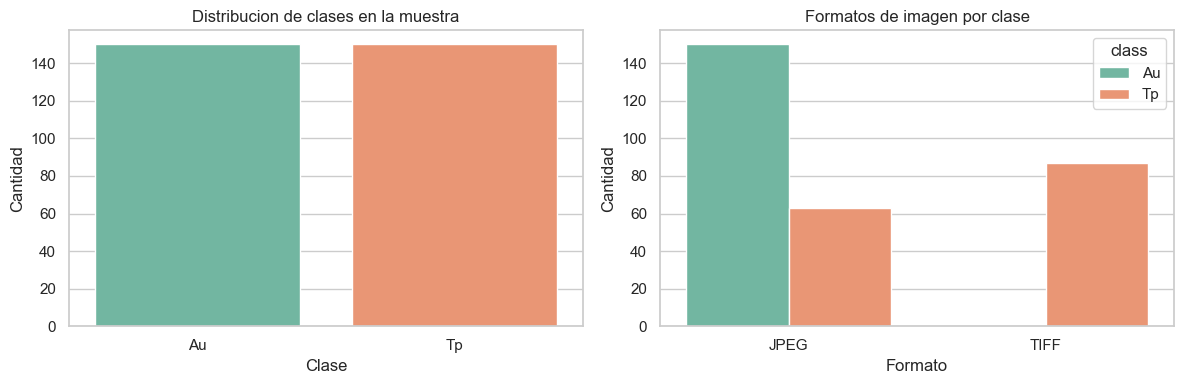

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x="class", hue="class", palette="Set2", ax=axes[0], legend=False)
axes[0].set_title("Distribucion de clases en la muestra")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Cantidad")

sns.countplot(data=df, x="format", hue="class", palette="Set2", ax=axes[1])
axes[1].set_title("Formatos de imagen por clase")
axes[1].set_xlabel("Formato")
axes[1].set_ylabel("Cantidad")

plt.tight_layout()
plt.show()

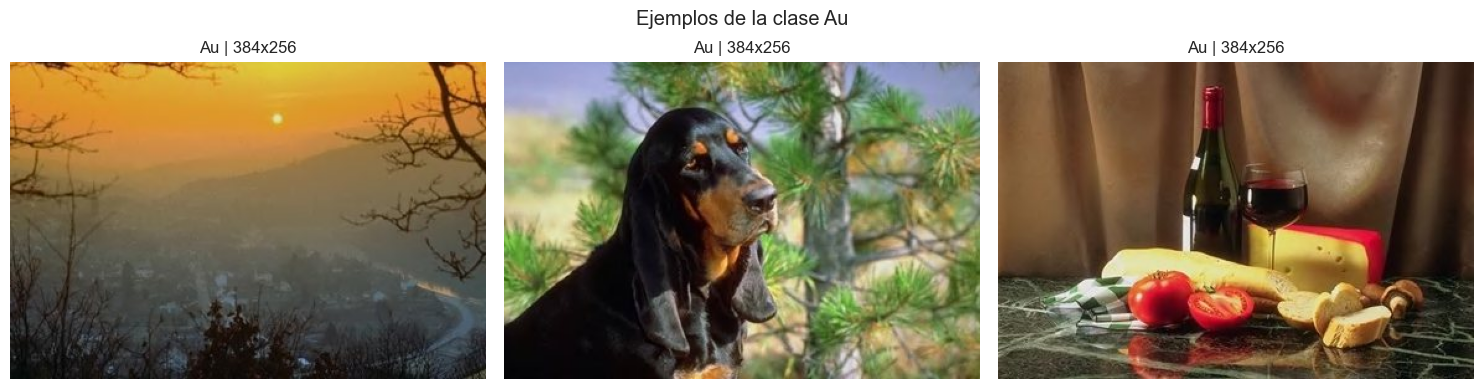

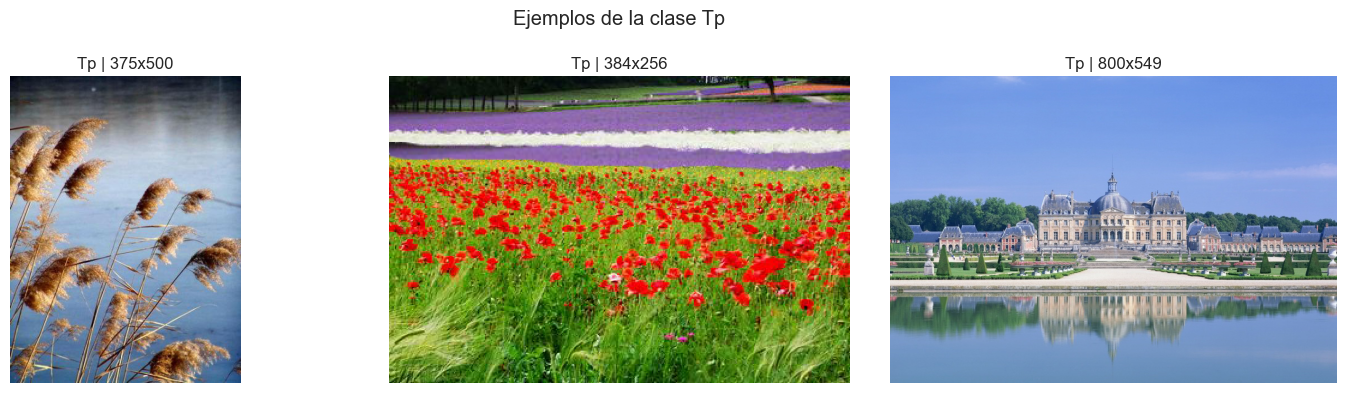

In [6]:
def plot_samples(df, class_label, num_samples=3):
    class_df = df[df["class"] == class_label]

    if class_df.empty:
        print(f"No hay imagenes disponibles para la clase {class_label}.")
        return

    num_samples = min(num_samples, len(class_df))
    samples = class_df.sample(num_samples, random_state=RANDOM_SEED)

    fig, axes = plt.subplots(1, num_samples, figsize=(5 * num_samples, 4))
    if num_samples == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, samples.iterrows()):
        try:
            with Image.open(row["filepath"]) as img:
                ax.imshow(img)
                ax.set_title(f"{class_label} | {row['width']}x{row['height']}")
                ax.axis("off")
        except Exception:
            ax.set_title("Imagen no disponible")
            ax.axis("off")

    plt.suptitle(f"Ejemplos de la clase {class_label}")
    plt.tight_layout()
    plt.show()


plot_samples(df, "Au")
plot_samples(df, "Tp")

## 5. Comparacion entre clases

Comparamos distribuciones de tamano, dimensiones y metricas globales de color para detectar diferencias preliminares entre `Au` y `Tp`.

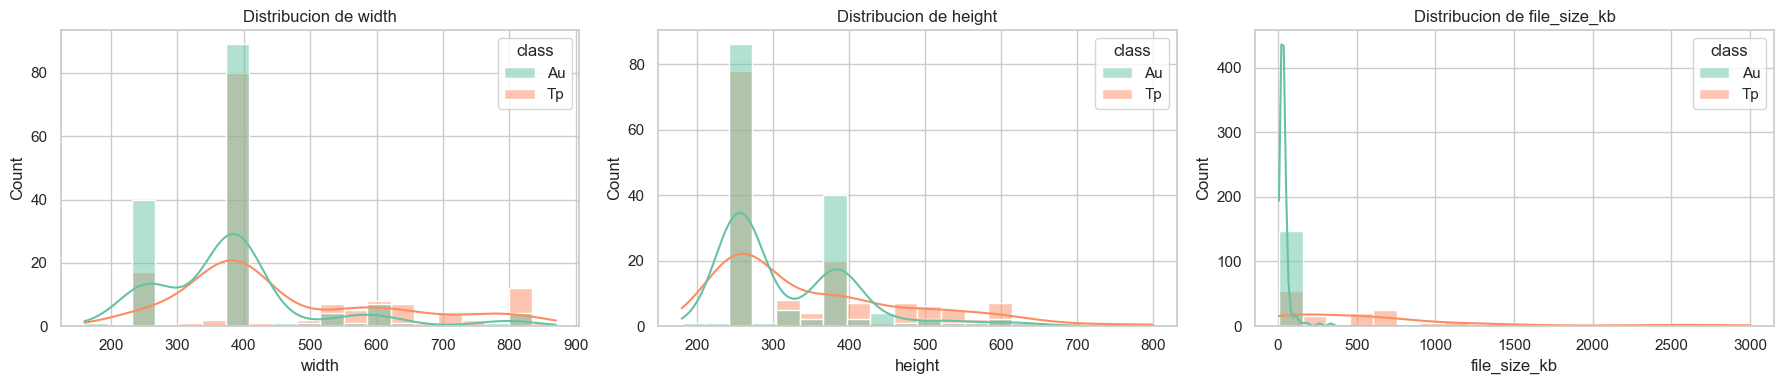

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(data=df, x="width", hue="class", bins=20, kde=True, ax=axes[0], palette="Set2")
axes[0].set_title("Distribucion de width")

sns.histplot(data=df, x="height", hue="class", bins=20, kde=True, ax=axes[1], palette="Set2")
axes[1].set_title("Distribucion de height")

sns.histplot(data=df, x="file_size_kb", hue="class", bins=20, kde=True, ax=axes[2], palette="Set2")
axes[2].set_title("Distribucion de file_size_kb")

plt.tight_layout()
plt.show()

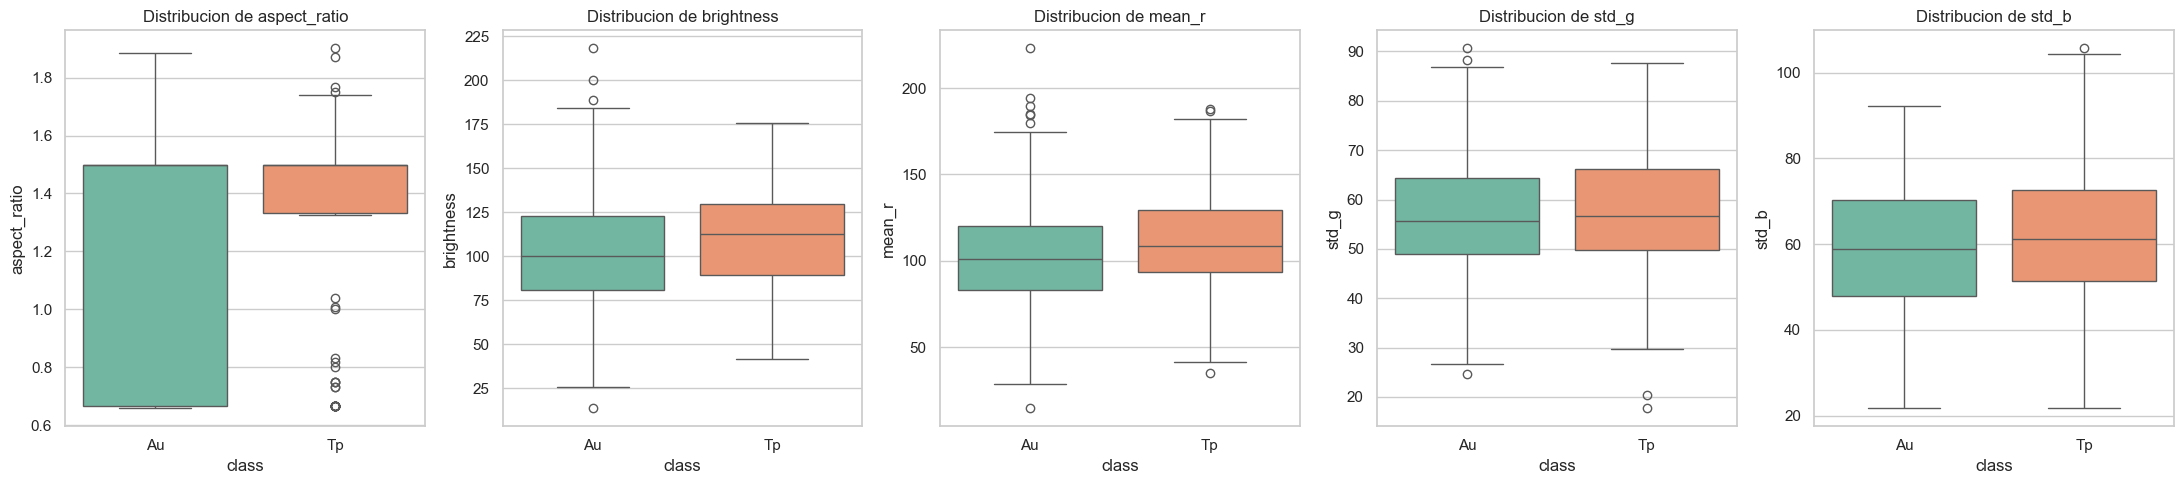

In [8]:
features_to_plot = ["aspect_ratio", "brightness", "mean_r", "std_g", "std_b"]
fig, axes = plt.subplots(1, len(features_to_plot), figsize=(22, 5))

for i, feature in enumerate(features_to_plot):
    sns.boxplot(data=df, x="class", y=feature, hue="class", palette="Set2", ax=axes[i], legend=False)
    axes[i].set_title(f"Distribucion de {feature}")

plt.tight_layout()
plt.show()

In [9]:
summary_cols = [
    "width", "height", "aspect_ratio", "file_size_kb",
    "mean_r", "mean_g", "mean_b", "std_r", "std_g", "std_b", "brightness"
]

df.groupby("class")[summary_cols].agg(["mean", "median", "std"]).round(2)

width                 height                aspect_ratio               \
         mean median     std    mean median     std         mean median   std   
class                                                                           
Au     380.83  384.0  118.96  316.55  256.0   85.71         1.26    1.5  0.38   
Tp     460.07  384.0  158.30  352.23  256.0  126.22         1.36    1.5  0.32   

      file_size_kb  ...  std_r  std_g                std_b                \
              mean  ...    std   mean median    std   mean median    std   
class               ...                                                    
Au           38.46  ...  12.39  56.82  55.69  12.70  58.97  58.89  16.05   
Tp          612.29  ...  13.30  57.05  56.74  13.32  61.92  61.08  16.73   

      brightness                 
            mean  median    std  
class                            
Au        104.08   99.93  34.82  
Tp        109.62  112.38  27.46  

[2 rows x 33 columns]

## 6. Seleccion preliminar de caracteristicas utiles

Evaluamos relaciones simples entre variables numericas para identificar caracteristicas potencialmente utiles y posibles redundancias.

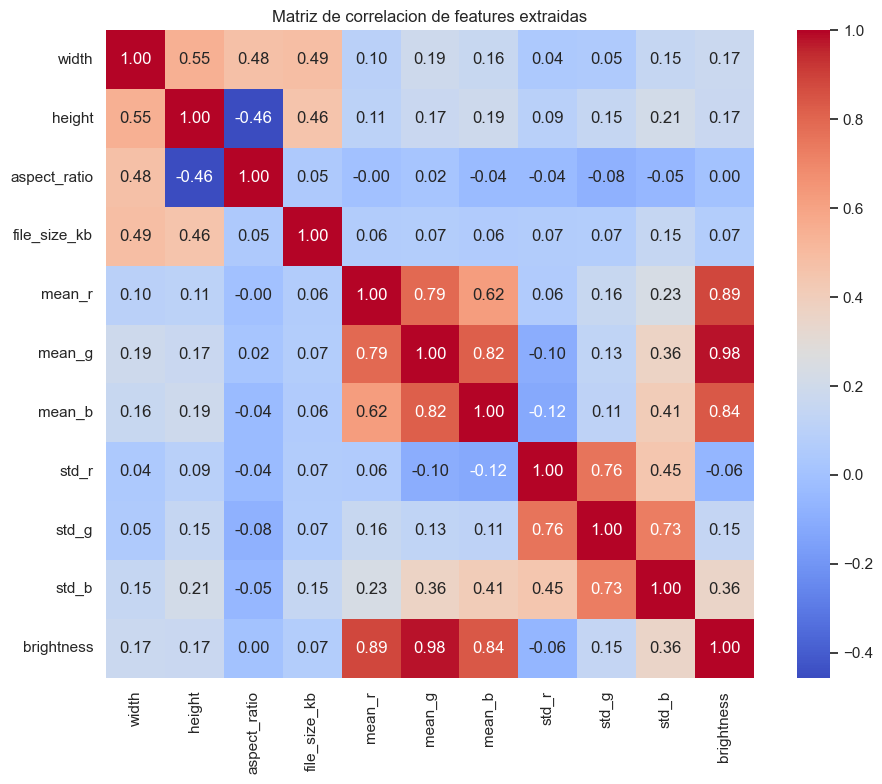

In [10]:
numeric_cols = [
    "width", "height", "aspect_ratio", "file_size_kb",
    "mean_r", "mean_g", "mean_b", "std_r", "std_g", "std_b", "brightness"
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Matriz de correlacion de features extraidas")
plt.tight_layout()
plt.show()

In [11]:
candidate_features = ["file_size_kb", "aspect_ratio", "brightness", "std_r", "std_g", "std_b"]
df[candidate_features + ["class"]].head()

,file_size_kb,aspect_ratio,brightness,std_r,std_g,std_b,class
0,30.693359,1.500000,108.592909,53.048098,57.934289,69.661971,Au
1,27.795898,0.666667,130.214670,44.677088,47.778942,57.221192,Au
2,35.111328,0.666667,86.920437,53.257769,54.684212,47.239983,Au
3,43.175781,1.500000,89.615874,71.321328,73.965064,51.953463,Au
4,25.154297,1.500000,97.399851,49.124660,53.387014,64.344287,Au


## Conclusiones 

El análisis exploratorio del dataset CASIA 2.0 permitió comprender mejor la naturaleza de las imágenes auténticas y manipuladas, así como identificar patrones relevantes en sus características. A partir del EDA, se observó que variables como el tamaño del archivo, el brillo y la variabilidad en los canales de color presentan cierto potencial para diferenciar entre ambas clases, aunque existe un grado considerable de solapamiento que sugiere que el problema no es trivial. La ingeniería de características realizada permitió transformar la información visual en variables numéricas interpretables y de bajo costo computacional, facilitando su uso en modelos de clasificación. Con base en el análisis de correlación y la exploración de distribuciones, se seleccionó un subconjunto de características que equilibra simplicidad y capacidad descriptiva, reduciendo redundancias innecesarias. En general, esta fase sienta una base sólida para el desarrollo de modelos en etapas posteriores, aunque será necesario validar empíricamente la utilidad de las características seleccionadas y considerar la incorporación de nuevas variables más robustas para mejorar el desempeño del modelo.
